<a href="https://colab.research.google.com/github/roboticengguseratvit/SAMM/blob/main/SAMM_Safety.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#create the folder
import os

SAFETY_DIR = "/content/SAMM_Safety"

os.makedirs(SAFETY_DIR, exist_ok=True)

print("SAMM_Safety folder created:")
print(SAFETY_DIR)

SAMM_Safety folder created:
/content/SAMM_Safety


In [2]:
#ceate samm_safety.py
%%writefile /content/SAMM_Safety/samm_safety.py

import os
import cv2
import torch
import numpy as np

from PIL import Image
from ultralytics import YOLO
from transformers import CLIPProcessor, CLIPModel


class SAMMSafety:

    # ---------------------------------------------------------
    # INITIALIZATION
    # ---------------------------------------------------------

    def __init__(
        self,
        pose_model="yolo11n-pose.pt",
        clip_model="openai/clip-vit-base-patch32",
        fall_threshold=0.60,
        min_consecutive_frames=3,
        frame_skip=5
    ):

        self.fall_threshold = fall_threshold
        self.min_consecutive_frames = min_consecutive_frames
        self.frame_skip = frame_skip

        # YOLO11n Pose
        self.pose_model = YOLO(
            pose_model
        )

        # Device
        self.device = (
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

        # CLIP
        self.clip_model = CLIPModel.from_pretrained(
            clip_model
        )

        self.clip_processor = CLIPProcessor.from_pretrained(
            clip_model
        )

        self.clip_model = self.clip_model.to(
            self.device
        )

        # Same labels used in the original notebook
        self.labels = [
            "a person sleeping in bed",
            "a person lying down and resting",
            "a person who has fallen on the floor",
            "a person sitting normally",
            "a person standing normally",
            "a person walking normally"
        ]

        self.fall_index = self.labels.index(
            "a person who has fallen on the floor"
        )


    # ---------------------------------------------------------
    # CONVERT CLIP LABEL TO ROBOT STATE
    # ---------------------------------------------------------

    def label_to_state(self, label):

        if "sleeping" in label:
            return "SLEEPING"

        elif "fallen" in label:
            return "FALL"

        elif "lying down" in label:
            return "LYING / RESTING"

        elif "sitting" in label:
            return "SITTING"

        elif "standing" in label:
            return "STANDING"

        elif "walking" in label:
            return "WALKING"

        return "UNKNOWN"


    # ---------------------------------------------------------
    # CLIP PERSON STATE DETECTION
    # ---------------------------------------------------------

    def detect_person_state(self, image):

        if isinstance(image, str):

            image = Image.open(
                image
            ).convert("RGB")

        elif isinstance(image, np.ndarray):

            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )

            image = Image.fromarray(
                image
            )

        else:

            image = image.convert(
                "RGB"
            )

        inputs = self.clip_processor(
            text=self.labels,
            images=image,
            return_tensors="pt",
            padding=True
        )

        inputs = {
            key: value.to(self.device)
            for key, value in inputs.items()
        }

        with torch.no_grad():

            outputs = self.clip_model(
                **inputs
            )

            probabilities = (
                outputs
                .logits_per_image
                .softmax(dim=1)[0]
            )

        scores = (
            probabilities
            .cpu()
            .numpy()
        )

        # Specific FALL probability
        fall_score = float(
            scores[self.fall_index]
        )

        # Highest-scoring state
        best_index = int(
            np.argmax(scores)
        )

        best_label = self.labels[
            best_index
        ]

        best_score = float(
            scores[best_index]
        )

        state = self.label_to_state(
            best_label
        )

        return {
            "state": state,
            "confidence": best_score,
            "fall_score": fall_score,
            "scores": {
                label: float(score)
                for label, score
                in zip(self.labels, scores)
            }
        }


    # ---------------------------------------------------------
    # SINGLE IMAGE PREDICTION
    # ---------------------------------------------------------

    def predict(self, image):

        result = self.detect_person_state(
            image
        )

        return {
            "state": result["state"],
            "confidence": result["confidence"],
            "fall_score": result["fall_score"],
            "fall_detected": (
                result["fall_score"]
                >= self.fall_threshold
            ),
            "scores": result["scores"]
        }


    # ---------------------------------------------------------
    # TEMPORAL FALL CONFIRMATION
    # ---------------------------------------------------------

    def confirm_fall(
        self,
        predictions
    ):

        consecutive = 0

        events = []

        for prediction in predictions:

            fall_score = prediction[
                "fall_score"
            ]

            if fall_score >= self.fall_threshold:

                consecutive += 1

            else:

                consecutive = 0

            prediction[
                "consecutive_fall_frames"
            ] = consecutive

            prediction[
                "fall_confirmed"
            ] = (
                consecutive
                >= self.min_consecutive_frames
            )

            if prediction[
                "fall_confirmed"
            ]:

                events.append(
                    prediction.copy()
                )

        return events


    # ---------------------------------------------------------
    # VIDEO ANALYSIS
    # ---------------------------------------------------------

    def process_video(
        self,
        video_path,
        output_path=None
    ):

        cap = cv2.VideoCapture(
            video_path
        )

        if not cap.isOpened():

            raise ValueError(
                f"Could not open video: {video_path}"
            )

        fps = cap.get(
            cv2.CAP_PROP_FPS
        )

        if fps <= 0:
            fps = 30

        width = int(
            cap.get(
                cv2.CAP_PROP_FRAME_WIDTH
            )
        )

        height = int(
            cap.get(
                cv2.CAP_PROP_FRAME_HEIGHT
            )
        )

        if output_path is not None:

            out = cv2.VideoWriter(
                output_path,
                cv2.VideoWriter_fourcc(
                    *"mp4v"
                ),
                fps,
                (width, height)
            )

        else:

            out = None

        frame_count = 0

        predictions = []

        while True:

            ret, frame = cap.read()

            if not ret:
                break

            frame_count += 1

            # Process every Nth frame
            if (
                frame_count
                % self.frame_skip
                != 0
            ):

                if out is not None:
                    out.write(frame)

                continue

            # ---------------------------------------------
            # YOLO11n Pose
            # ---------------------------------------------

            pose_results = self.pose_model(
                frame,
                conf=0.4,
                verbose=False
            )

            # ---------------------------------------------
            # CLIP
            # ---------------------------------------------

            result = self.detect_person_state(
                frame
            )

            state = result["state"]

            confidence = result[
                "confidence"
            ]

            fall_score = result[
                "fall_score"
            ]

            prediction = {

                "frame": frame_count,

                "state": state,

                "confidence": confidence,

                "fall_score": fall_score,

                "consecutive_fall_frames": 0,

                "fall_confirmed": False
            }

            predictions.append(
                prediction
            )

            # ---------------------------------------------
            # Visualization
            # ---------------------------------------------

            annotated = pose_results[
                0
            ].plot()

            text = (
                f"{state} | "
                f"FALL score: "
                f"{fall_score:.1%}"
            )

            cv2.putText(
                annotated,
                text,
                (30, 50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (
                    (0, 0, 255)
                    if state == "FALL"
                    else (0, 255, 0)
                ),
                3
            )

            if out is not None:
                out.write(
                    annotated
                )

        cap.release()

        if out is not None:
            out.release()

        # ---------------------------------------------
        # Temporal confirmation
        # ---------------------------------------------

        fall_events = self.confirm_fall(
            predictions
        )

        return {
            "video": video_path,

            "frames_total": frame_count,

            "frames_analyzed": len(
                predictions
            ),

            "predictions": predictions,

            "fall_events": fall_events,

            "fall_confirmed": (
                len(fall_events) > 0
            )
        }


    # ---------------------------------------------------------
    # SAFETY DECISION
    # ---------------------------------------------------------

    def safety_action(
        self,
        fall_confirmed
    ):

        if fall_confirmed:

            return {
                "status": "FALL_DETECTED",
                "action": "EMERGENCY_ALERT"
            }

        return {
            "status": "NORMAL",
            "action": "NO_ACTION"
        }

Writing /content/SAMM_Safety/samm_safety.py


In [3]:
#config.json
import json

config = {
    "pose_model": "yolo11n-pose.pt",
    "clip_model": "openai/clip-vit-base-patch32",
    "fall_threshold": 0.60,
    "min_consecutive_frames": 3,
    "frame_skip": 5,
    "pose_confidence": 0.40
}

with open(
    "/content/SAMM_Safety/config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print("config.json created.")

config.json created.


In [4]:
#requirements
requirements = """ultralytics
transformers
torch
torchvision
opencv-python
numpy
pandas
matplotlib
scikit-learn
Pillow
"""

with open(
    "/content/SAMM_Safety/requirements.txt",
    "w"
) as f:

    f.write(requirements)

print("requirements.txt created.")

requirements.txt created.


In [5]:
#ReadMe
readme = [
    "# SAMM Safety",
    "",
    "Vision-based fall detection subsystem for the Smart Assistive Mobile Manipulator (SAMM).",
    "",
    "## Pipeline",
    "",
    "Input video -> YOLO11n-Pose -> CLIP person-state classification -> FALL score -> temporal confirmation -> safety alert",
    "",
    "## Models",
    "",
    "YOLO11n-Pose",
    "",
    "CLIP: openai/clip-vit-base-patch32",
    "",
    "## Person states",
    "",
    "SLEEPING",
    "LYING / RESTING",
    "FALL",
    "SITTING",
    "STANDING",
    "WALKING",
    "",
    "## Fall confirmation",
    "",
    "Fall threshold: 0.60",
    "",
    "Minimum consecutive analyzed frames: 3",
    "",
    "Frame skip: 5",
    "",
    "A fall is confirmed when the CLIP FALL score remains at or above the threshold for at least three consecutive analyzed frames.",
    "",
    "## Review III result",
    "",
    "The original video experiment analyzed 79 frames.",
    "",
    "The fall sequence produced FALL scores above the threshold for consecutive frames and triggered confirmation at frame 120.",
    "",
    "The separate non-fall video test also produced a false positive, demonstrating that further validation and tuning are required.",
    "",
    "## Reusable API",
    "",
    "from samm_safety import SAMMSafety",
    "",
    "safety = SAMMSafety()",
    "",
    "result = safety.predict(image)",
    "",
    "video_result = safety.process_video(video_path)",
    "",
    "action = safety.safety_action(video_result['fall_confirmed'])"
]

with open(
    "/content/SAMM_Safety/README.md",
    "w"
) as f:

    f.write("\n".join(readme))

print("README.md created.")

README.md created.


In [6]:
#evaluation results
evaluation = {
    "method": {
        "fall_threshold": 0.60,
        "minimum_consecutive_frames": 3,
        "frame_skip": 5
    },

    "fall_video": {
        "frames_analyzed": 79,
        "first_confirmed_fall_frame": 120,
        "fall_score_at_confirmation": 0.785184,
        "maximum_fall_score": 0.864033,
        "confirmed": True
    },

    "non_fall_video": {
        "frames_analyzed": 79,
        "maximum_fall_score": 0.864033,
        "false_positive": True,
        "trigger_frame": 120
    },

    "note": (
        "The current prototype demonstrates temporal fall confirmation, "
        "but the non-fall test produced a false positive. "
        "Further validation and threshold/model tuning are required."
    )
}

with open(
    "/content/SAMM_Safety/evaluation_results.json",
    "w"
) as f:

    json.dump(
        evaluation,
        f,
        indent=4
    )

print("evaluation_results.json created.")

evaluation_results.json created.


In [7]:
#checking package
import os

print("SAMM_Safety contents:\n")

for item in sorted(
    os.listdir("/content/SAMM_Safety")
):

    print(" -", item)

SAMM_Safety contents:

 - README.md
 - config.json
 - evaluation_results.json
 - requirements.txt
 - samm_safety.py


In [9]:
import sys

# Install required packages from requirements.txt
!pip install -r /content/SAMM_Safety/requirements.txt

sys.path.insert(
    0,
    "/content/SAMM_Safety"
)

from samm_safety import SAMMSafety

print("SAMMSafety imported successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 9.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
SAMMSafety imported successfully.


In [10]:
safety = SAMMSafety()

print("SAMM Safety model loaded.")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

SAMM Safety model loaded.


In [11]:
#live webcam recorder
from IPython.display import Javascript, display, Video
from google.colab import output
from base64 import b64decode

def record_webcam_video(seconds=8, filename="/content/samm_live_test.webm"):

    js = Javascript(f"""
    async function recordVideo() {{

        const div = document.createElement('div');

        const video = document.createElement('video');
        video.style.display = 'block';
        video.style.width = '640px';
        video.style.maxWidth = '100%';

        const stream = await navigator.mediaDevices.getUserMedia({{
            video: true,
            audio: false
        }});

        video.srcObject = stream;

        document.body.appendChild(div);
        div.appendChild(video);

        await video.play();

        google.colab.output.setIframeHeight(
            document.documentElement.scrollHeight,
            true
        );

        const recorder = new MediaRecorder(stream);

        let chunks = [];

        recorder.ondataavailable = event => {{
            if (event.data.size > 0) {{
                chunks.push(event.data);
            }}
        }};

        recorder.start();

        await new Promise(resolve =>
            setTimeout(resolve, {seconds * 1000})
        );

        recorder.stop();

        await new Promise(resolve =>
            recorder.onstop = resolve
        );

        stream.getVideoTracks()[0].stop();

        div.remove();

        const blob = new Blob(
            chunks,
            {{type: "video/webm"}}
        );

        const arrayBuffer =
            await blob.arrayBuffer();

        const bytes =
            new Uint8Array(arrayBuffer);

        let binary = "";

        for (let i = 0; i < bytes.length; i++) {{
            binary += String.fromCharCode(bytes[i]);
        }}

        return btoa(binary);
    }}

    recordVideo();
    """)

    display(js)

    data = output.eval_js(
        "recordVideo()"
    )

    binary = b64decode(data)

    with open(filename, "wb") as f:
        f.write(binary)

    print("Live camera recording saved:")
    print(filename)

    return filename

In [18]:
#record a normal test
normal_video = record_webcam_video(
    seconds=8,
    filename="/content/samm_normal_test.webm"
)

<IPython.core.display.Javascript object>

Live camera recording saved:
/content/samm_normal_test.webm


In [19]:
#convert webm to mp4
!ffmpeg -y -i /content/samm_normal_test.webm \
    /content/samm_normal_test.mp4

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

In [20]:
normal_video_mp4 = "/content/samm_normal_test.mp4"

In [21]:
#run SAMM model
from samm_safety import SAMMSafety

safety = SAMMSafety()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [22]:
normal_result = safety.process_video(
    normal_video_mp4,
    output_path="/content/samm_normal_result.mp4"
)

print("Frames analyzed:",
      normal_result["frames_analyzed"])

print("Fall confirmed:",
      normal_result["fall_confirmed"])

print("Fall events:",
      len(normal_result["fall_events"]))

Frames analyzed: 23
Fall confirmed: False
Fall events: 0


In [36]:
#fall test
fall_video = record_webcam_video(
    seconds=8,
    filename="/content/samm_fall_test.webm"
)

<IPython.core.display.Javascript object>

Live camera recording saved:
/content/samm_fall_test.webm


In [37]:
!ffmpeg -y -i /content/samm_fall_test.webm \
    /content/samm_fall_test.mp4

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

In [38]:
fall_result = safety.process_video(
    "/content/samm_fall_test.mp4",
    output_path="/content/samm_fall_result.mp4"
)

print("Frames analyzed:",
      fall_result["frames_analyzed"])

print("Fall confirmed:",
      fall_result["fall_confirmed"])

print("Fall events:",
      len(fall_result["fall_events"]))

Frames analyzed: 24
Fall confirmed: False
Fall events: 0


In [29]:
display(
    Video(
        "/content/samm_fall_result.mp4",
        embed=True
    )
)

In [49]:
from google.colab import files

uploaded = files.upload()

video_path = next(iter(uploaded.keys()))
print("Uploaded video:", video_path)

Saving istockphoto-2218359872-640_adpp_is.mp4 to istockphoto-2218359872-640_adpp_is.mp4
Uploaded video: istockphoto-2218359872-640_adpp_is.mp4


In [50]:
import cv2

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("ERROR: Could not open video")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frames / fps if fps > 0 else 0

    print("Video loaded successfully")
    print("FPS:", fps)
    print("Frames:", frames)
    print("Duration:", round(duration, 2), "seconds")

cap.release()

Video loaded successfully
FPS: 25.0
Frames: 383
Duration: 15.32 seconds


In [51]:
result = safety.process_video(
    video_path,
    output_path="/content/fall_test_result.mp4"
)

print("Frames analyzed:", len(result["predictions"]))
print("Fall confirmed:", result["fall_confirmed"])
print("Fall events:", len(result["fall_events"]))

Frames analyzed: 76
Fall confirmed: False
Fall events: 0


In [42]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded.keys()))
print("Uploaded image:", image_path)

Saving fall pic1.jfif to fall pic1.jfif
Uploaded image: fall pic1.jfif


In [43]:
result = safety.predict(image_path)

print("State:", result["state"])
print("Confidence:", result["confidence"])
print("Fall score:", result["fall_score"])
print("Fall detected:", result["fall_detected"])

State: FALL
Confidence: 0.7696034908294678
Fall score: 0.7696034908294678
Fall detected: True


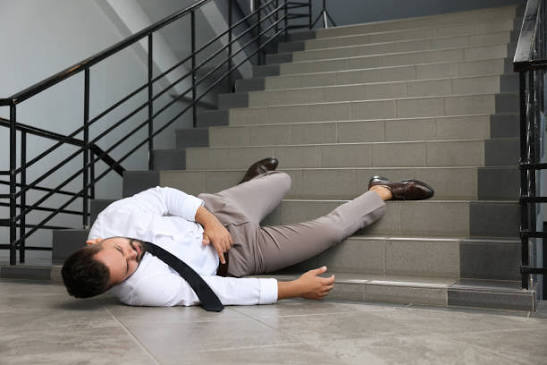


Prediction:
State: FALL
Confidence: 76.96%
Fall score: 76.96%
Fall detected: True


In [44]:
from IPython.display import display
from PIL import Image

display(Image.open(image_path))

print("\nPrediction:")
print("State:", result["state"])
print("Confidence:", f'{result["confidence"]:.2%}')
print("Fall score:", f'{result["fall_score"]:.2%}')
print("Fall detected:", result["fall_detected"])

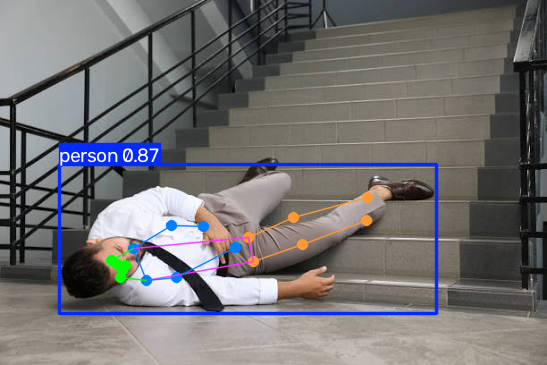

In [46]:
import cv2
from IPython.display import display
from PIL import Image

img = cv2.imread(image_path)

# Use the confidence value directly
pose_results = safety.pose_model(
    img,
    conf=0.40,
    verbose=False
)

annotated = pose_results[0].plot()

display(Image.fromarray(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)))

In [47]:
#testing fall video
video_path = "/content/fall.mp4"

result = safety.process_video(
    video_path,
    output_path="/content/fall_test_result.mp4"
)

print("Frames analyzed:", len(result["predictions"]))
print("Fall confirmed:", result["fall_confirmed"])
print("Fall events:", len(result["fall_events"]))

Frames analyzed: 50
Fall confirmed: False
Fall events: 0


In [48]:
for i, p in enumerate(result["predictions"]):
    print(
        f"Frame {p['frame']}: "
        f"State={p['state']}, "
        f"Confidence={p['confidence']:.3f}, "
        f"Fall score={p['fall_score']:.3f}"
    )

Frame 5: State=SITTING, Confidence=0.728, Fall score=0.015
Frame 10: State=SITTING, Confidence=0.740, Fall score=0.015
Frame 15: State=SITTING, Confidence=0.757, Fall score=0.015
Frame 20: State=SITTING, Confidence=0.756, Fall score=0.016
Frame 25: State=SITTING, Confidence=0.722, Fall score=0.018
Frame 30: State=SITTING, Confidence=0.768, Fall score=0.013
Frame 35: State=SITTING, Confidence=0.768, Fall score=0.034
Frame 40: State=SITTING, Confidence=0.757, Fall score=0.026
Frame 45: State=SITTING, Confidence=0.693, Fall score=0.015
Frame 50: State=SITTING, Confidence=0.728, Fall score=0.011
Frame 55: State=SITTING, Confidence=0.669, Fall score=0.031
Frame 60: State=SITTING, Confidence=0.805, Fall score=0.021
Frame 65: State=SITTING, Confidence=0.584, Fall score=0.022
Frame 70: State=SITTING, Confidence=0.363, Fall score=0.067
Frame 75: State=SITTING, Confidence=0.588, Fall score=0.031
Frame 80: State=SITTING, Confidence=0.533, Fall score=0.125
Frame 85: State=FALL, Confidence=0.392, F

In [52]:
result = safety.predict(image_path)

print("State:", result["state"])
print("Confidence:", f'{result["confidence"]:.2%}')
print("Fall score:", f'{result["fall_score"]:.2%}')
print("Fall detected:", result["fall_detected"])

State: FALL
Confidence: 76.96%
Fall score: 76.96%
Fall detected: True


In [53]:
import os
import json
import shutil

export_dir = "/content/SAMM_Safety_Export"

# Create export folder
os.makedirs(export_dir, exist_ok=True)

# Save configuration
config = {
    "pose_model": "yolo11n-pose.pt",
    "clip_model": "openai/clip-vit-base-patch32",
    "fall_threshold": 0.60,
    "min_consecutive_frames": 3,
    "frame_skip": 5,
    "pose_confidence": 0.40,
    "labels": [
        "sleeping",
        "lying/resting",
        "fallen",
        "sitting",
        "standing",
        "walking"
    ]
}

with open(os.path.join(export_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("Configuration saved.")

Configuration saved.


In [54]:
shutil.copy(
    "/content/SAMM_Safety/samm_safety.py",
    os.path.join(export_dir, "samm_safety.py")
)

print("samm_safety.py copied.")

samm_safety.py copied.


In [55]:
import glob

yolo_files = glob.glob("/content/**/yolo11n-pose.pt", recursive=True)

print("Found YOLO files:")
for f in yolo_files:
    print(f)

Found YOLO files:
/content/yolo11n-pose.pt


In [56]:
if yolo_files:
    shutil.copy(
        yolo_files[0],
        os.path.join(export_dir, "yolo11n-pose.pt")
    )
    print("YOLO11n-Pose weights copied.")
else:
    print("YOLO11n-Pose weights not found.")

YOLO11n-Pose weights copied.


In [57]:
if os.path.exists("/content/samm_fall_detection"):
    shutil.copytree(
        "/content/samm_fall_detection",
        os.path.join(export_dir, "samm_fall_detection"),
        dirs_exist_ok=True
    )
    print("CLIP model copied.")
else:
    print("CLIP saved model folder not found.")

CLIP saved model folder not found.


In [58]:
import os

clip_export_dir = "/content/SAMM_Safety_Export/clip_model"
os.makedirs(clip_export_dir, exist_ok=True)

# Save CLIP model
safety.clip_model.save_pretrained(clip_export_dir)

# Save CLIP processor
safety.clip_processor.save_pretrained(clip_export_dir)

print("CLIP model and processor saved to:")
print(clip_export_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

CLIP model and processor saved to:
/content/SAMM_Safety_Export/clip_model


In [59]:
import os

for root, dirs, files in os.walk("/content/SAMM_Safety_Export/clip_model"):
    for file in files:
        print(os.path.join(root, file))

/content/SAMM_Safety_Export/clip_model/config.json
/content/SAMM_Safety_Export/clip_model/tokenizer.json
/content/SAMM_Safety_Export/clip_model/processor_config.json
/content/SAMM_Safety_Export/clip_model/model.safetensors
/content/SAMM_Safety_Export/clip_model/tokenizer_config.json


In [60]:
import os

print("Export folder:")
for item in os.listdir("/content/SAMM_Safety_Export"):
    print(" -", item)

Export folder:
 - config.json
 - samm_safety.py
 - clip_model
 - yolo11n-pose.pt


In [62]:
import os

for root, dirs, files in os.walk("/content/SAMM_Safety_Export"):
    level = root.replace("/content/SAMM_Safety_Export", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}    {file}")

SAMM_Safety_Export/
    config.json
    samm_safety.py
    yolo11n-pose.pt
    clip_model/
        config.json
        tokenizer.json
        processor_config.json
        model.safetensors
        tokenizer_config.json


In [63]:
import shutil

zip_path = shutil.make_archive(
    "/content/SAMM_Safety_Export",
    "zip",
    "/content/SAMM_Safety_Export"
)

print("Exported:", zip_path)

Exported: /content/SAMM_Safety_Export.zip


In [64]:
from google.colab import files

files.download("/content/SAMM_Safety_Export.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>